# 숙제 시작

## 5번째 세그먼트 중고신입형

**작업계( 그림, 코스프레 등) 으로 인기( 트래픽, 팔로워)를 확보해 두었지만 버츄얼 규모는 작거나 신규인 스트리머**

예시 분석용 핵심 KPI : X_팔로워, 팬카페_가입자, 유튜브_구독자, 팬덤지수, 최고_팔로워

다시 정의 : 외부 커뮤니티(SNS, 유튜브 등)의 체급은 상위권이지만, 생방송(버추얼) 지표는 하위권~중위권인 스트리머

#### 조건1 : 플랫폼 이외의 외부 지표가 유의미한 영향력을 가졌는지 절대 수치로 검증

트위터, 유튜브, 팬카페 중 하나라도 두각을 보여야 함

- KPI 세팅: X_팔로워, 팬카페_가입자, 유튜브_구독자 중 하나라도 TOP 100


#### 조건2 : 버츄얼 체급은 아직 신입일 것

본업(버츄얼 이전 직업) 위주로 활동해서 아직 생방송 고정 시청자가 크지 않아야 함 

이전에 만들었던 유튜브_유입지수와 팬덤지수
- 분모 : 팔로워 
- 분자 : 외부 지표 (유튜브_구독자, 팬카페_가입자, X_팔로워)

-> 현재 플랫폼 체급이 작을수록 지수값이 커짐

-> 유튜브나 SNS 화력이 셀수록 지수값이 커짐

- 지수가 높다는 것 자체가 "본업(작업계) 인기에 비해 아직 방송 규모가 작다"는 것을 산술적으로 증명


- 유튜브_유입지수, 팬덤지수 중 하나라도 TOP 100

---

##### 조건1(외부 커뮤니티 체급 상위권)과 조건2(버츄얼 체급은 신입)를 동시에 만족하는 경우 

##### -> '중고신입형' 세그먼트로 분류

### 데이터 뽑기

조건2에서 팬심지수는 X팔로워랑 카페회원수를 같이봄


팬심지수(X&팬카페)에서 -> X 유입지수

$$ X\text{ 유입지수} = \frac{\log_{10}(X\_\text{팔로워} + 1)}{\log_{10}(\text{최고\_팔로워} + 1)} $$

In [1]:
import pandas as pd
import numpy as np

# 1. 데이터 불러오기
df = pd.read_csv('final_softcone.csv')


# X_유입지수 생성 (분모 0 처리를 위해 log10 적용 시 +1)
df['X_유입지수'] = np.log10(df['X_팔로워'] + 1) / np.log10(df['최고_팔로워'] + 1)

# inf(무한대)를 0으로 치환 (최고_팔로워가 0인 경우 대비)
df['X_유입지수'] = df['X_유입지수'].replace([np.inf, -np.inf], np.nan).fillna(0)

# =====================================================================
# [조건 1] 외부 커뮤니티 체급 상위권 (절대 수치 TOP 100)
# =====================================================================
top100_x = df[df['X_팔로워'] > 0].nlargest(200, 'X_팔로워').index
top100_yt = df[df['유튜브_구독자'] > 0].nlargest(200, '유튜브_구독자').index

cond1_idx = top100_x.union(top100_yt)
cond1_mask = df.index.isin(cond1_idx)

# =====================================================================
# [조건 2] 버츄얼 체급은 아직 신입일 것 (상한선 + 지수 TOP 100)
# =====================================================================

#mean_followers = df[df['최고_팔로워'] > 0]['최고_팔로워'].mean()
#upper_bound_mask = df['최고_팔로워'] <= mean_followers

# 2-2. 지표 비율 기준 TOP 100 추출 (유튜브와 X의 유입지수 활용)
top100_yt_inflow = df.nlargest(200, '유튜브_유입지수').index
top100_x_inflow = df.nlargest(200, 'X_유입지수').index

cond2_idx = top100_yt_inflow.union(top100_x_inflow)
index_mask = df.index.isin(cond2_idx)

# 최종 조건 2: 지수 상위권이면서 + 동시에 방송 체급은 평균 이하일 것
cond2_mask = index_mask 


# [최종 추출] 세그먼트 5: 중고신입형

segment_5_df = df[cond1_mask & cond2_mask]
segment_5_df = segment_5_df[segment_5_df['스트리머명'] != '브이레코드']

# 결과 확인 
print(f"[데이터 요약]")
print(f"1. 조건 1(외부 네임드) 통과자: {cond1_mask.sum()}명")
print(f"2. 조건 2(지수 상위 & 신입 체급) 통과자: {cond2_mask.sum()}명")
print("-" * 40)
print(f"최종 세그먼트 5 (중고신입형) 발굴 인원: {len(segment_5_df)}명")

# CSV 저장
#segment_5_df.to_csv('segment5_used_newbie_v2.csv', index=False, encoding='utf-8-sig')

display_cols = ['스트리머명', '최고_팔로워', 'X_팔로워', '유튜브_구독자', '유튜브_유입지수', 'X_유입지수']
(segment_5_df[display_cols].sort_values(by='X_유입지수', ascending=False).tail(50))

[데이터 요약]
1. 조건 1(외부 네임드) 통과자: 353명
2. 조건 2(지수 상위 & 신입 체급) 통과자: 378명
----------------------------------------
최종 세그먼트 5 (중고신입형) 발굴 인원: 68명


,스트리머명,최고_팔로워,X_팔로워,유튜브_구독자,유튜브_유입지수,X_유입지수
4711,오투 2,2492,184000,0,-100.0,1.549971
5172,몬드몬드,399,10000,16,-52.7,1.537260
5240,냥족,596,15602,0,-100.0,1.510536
7481,YUDOK,254,4204,83,-20.0,1.505799
4671,그잉,680,16000,23600,54.3,1.483914
6466,DODOYUKI,295,4294,259,-2.3,1.470067
1765,천수천수,759,17000,0,-100.0,1.468500
5824,히이인,215,2634,11,-53.8,1.465345
8549,아연화,470,7423,3180,31.0,1.448039
6358,모브,512,8253,0,-100.0,1.445201


### 유튜브 유입지수, X_유입지수 기준

In [2]:

yt_inflow_cut = df.nlargest(200, '유튜브_유입지수')['유튜브_유입지수'].min()

# 2. X 유입지수 TOP 100의 최솟값 (100위의 점수)
x_inflow_cut = df.nlargest(200, 'X_유입지수')['X_유입지수'].min()

print(f"[지수 커트라인 확인]")
print(f"1. 유튜브 유입지수 TOP 100 컷: {yt_inflow_cut:.4f}")
print(f"2. X_유입지수 TOP 100 컷: {x_inflow_cut:.4f}")
print("-" * 40)

if len(segment_5_df) > 0:
    print(f"최종 스트리머의 지수 분포")
    print(f"- 유튜브 유입지수 범위: {segment_5_df['유튜브_유입지수'].min():.2f} ~ {segment_5_df['유튜브_유입지수'].max():.2f}")
    print(f"- X_유입지수 범위: {segment_5_df['X_유입지수'].min():.2f} ~ {segment_5_df['X_유입지수'].max():.2f}")
else:
    print("검색된 인원이 없습니다. 로직을 다시 확인해주세요.")

[지수 커트라인 확인]
1. 유튜브 유입지수 TOP 100 컷: 54.2000
2. X_유입지수 TOP 100 컷: 1.2233
----------------------------------------
최종 스트리머의 지수 분포
- 유튜브 유입지수 범위: -100.00 ~ 135.90
- X_유입지수 범위: 0.00 ~ 3.26


### 유튜브 팔로워, X 팔로워 기준

In [3]:

# 1. 유튜브 구독자
yt_subs_cut = df[df['유튜브_구독자'] > 0].nlargest(200, '유튜브_구독자')['유튜브_구독자'].min()

# 2. X(트위터) 팔로워 
x_fol_cut = df[df['X_팔로워'] > 0].nlargest(200, 'X_팔로워')['X_팔로워'].min()

print(f"[조건 1: 외부 영향력 커트라인]")
print(f"1. 유튜브 구독자 TOP 100 컷: {yt_subs_cut:,}명")
print(f"2. X(트위터) 팔로워 TOP 100 컷: {x_fol_cut:,}명")
print("-" * 40)

# 4. 최종 27명의 실제 외부 체급 평균 확인
if len(segment_5_df) > 0:
    print(f"최종 발굴된 스트리머의 평균 체급")
    print(f"- 평균 유튜브 구독자: {segment_5_df['유튜브_구독자'].mean():,.0f}명")
    print(f"- 평균 X 팔로워: {segment_5_df['X_팔로워'].mean():,.0f}명")
    print(f"- 평균 최고 팔로워(방송): {segment_5_df['최고_팔로워'].mean():,.0f}명")

[조건 1: 외부 영향력 커트라인]
1. 유튜브 구독자 TOP 100 컷: 47,800명
2. X(트위터) 팔로워 TOP 100 컷: 2,634명
----------------------------------------
최종 발굴된 스트리머의 평균 체급
- 평균 유튜브 구독자: 24,323명
- 평균 X 팔로워: 30,017명
- 평균 최고 팔로워(방송): 1,178명


## 세그먼트5 유입 경로별 비중

C:\Users\anna3\AppData\Local\Temp\ipykernel_16104\2210741574.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=segment_5_df, x='유입경로', palette=palette, order=order, edgecolor='black', linewidth=1)


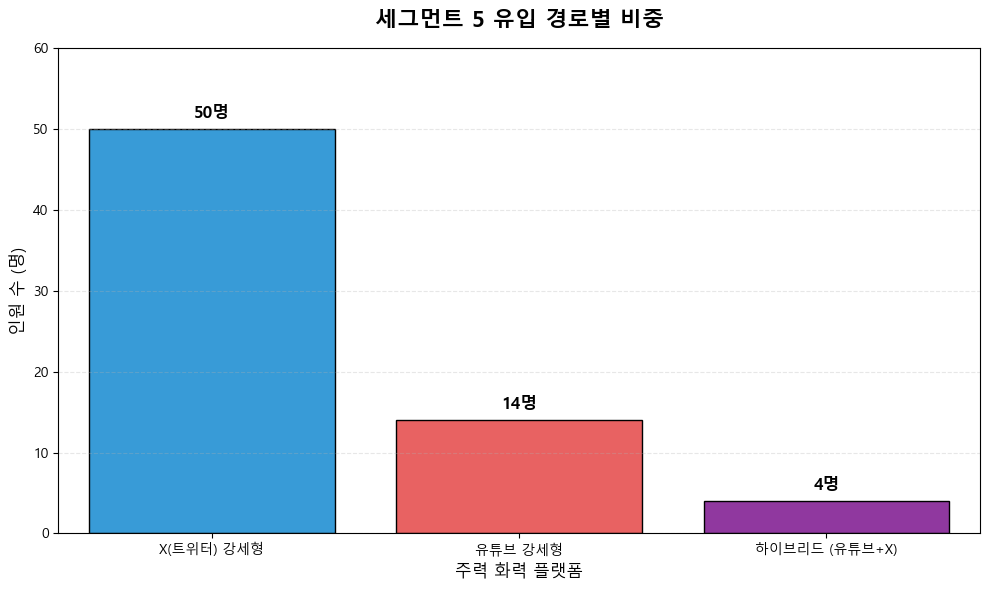

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =====================================================================
# 1. '유입경로' 컬럼 생성 (KeyError 해결)
# =====================================================================
# 전체 데이터(df)에서 지수 컷오프 계산
yt_inflow_cut = df.nlargest(200, '유튜브_유입지수')['유튜브_유입지수'].min()
x_inflow_cut = df.nlargest(200, 'X_유입지수')['X_유입지수'].min()

def assign_group(row):
    is_yt = row['유튜브_유입지수'] >= yt_inflow_cut
    is_x = row['X_유입지수'] >= x_inflow_cut
    
    if is_yt and is_x: return '하이브리드 (유튜브+X)'
    if is_yt: return '유튜브 강세형'
    if is_x: return 'X(트위터) 강세형'
    return '기타'

# 경고 방지를 위해 카피 후 컬럼 추가
segment_5_df = segment_5_df.copy()
segment_5_df['유입경로'] = segment_5_df.apply(assign_group, axis=1)


# =====================================================================
# 2. 유입 경로별 비중 막대그래프 시각화
# =====================================================================
plt.figure(figsize=(10, 6))
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 색상 팔레트 유지
palette = {
    'X(트위터) 강세형': '#1DA1F2',     
    '유튜브 강세형': '#FF4B4B',        
    '하이브리드 (유튜브+X)': '#9C27B0',  
    '기타(기준치 근접)': '#7F8C8D'
}

# 정렬 순서 지정 (기타 제외하고 3개만 깔끔하게)
order = ['X(트위터) 강세형', '유튜브 강세형', '하이브리드 (유튜브+X)']

# 막대그래프 그리기
ax = sns.countplot(data=segment_5_df, x='유입경로', palette=palette, order=order, edgecolor='black', linewidth=1)

# 막대 위에 정확한 숫자(명수) 표기
for p in ax.patches:
    height = p.get_height()
    if height > 0: # 0명인 막대는 숫자 표시 안 함
        ax.annotate(f'{int(height)}명', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'bottom', 
                    fontsize=12, fontweight='bold', color='black', xytext=(0, 5), 
                    textcoords='offset points')

plt.title('세그먼트 5 유입 경로별 비중', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('주력 화력 플랫폼', fontsize=12)
plt.ylabel('인원 수 (명)', fontsize=12)

# Y축 상단 여유 공간 주기 (숫자 안 잘리게)
plt.ylim(0, segment_5_df['유입경로'].value_counts().max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

세그먼트 5를 분류한 결과 트위터 강세형은 51명, 유튜브 강세형은 14명, 유튜브와 X가 모두 강세인 하이브리드형은 4명이 집계되었다.

## 내부 체급 대비 외부 플랫폼 지표가 높은 TOP 4

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

segment_5_df['외부_활성도_비율'] = (segment_5_df['X_팔로워'] + segment_5_df['유튜브_구독자']) / segment_5_df['최고_팔로워']


group_hb = segment_5_df[segment_5_df['유입경로'] == '하이브리드 (유튜브+X)'].sort_values('외부_활성도_비율', ascending=False)
group_yt = segment_5_df[segment_5_df['유입경로'] == '유튜브 강세형'].sort_values('외부_활성도_비율', ascending=False)
group_x = segment_5_df[segment_5_df['유입경로'] == 'X(트위터) 강세형'].sort_values('외부_활성도_비율', ascending=False)

# 3. 그래프용 TOP 4 추출 
# 그래프 시각화 시에는 '큰 값이 위로' 오게 하려고 다시 sort(ascending=True)를 사용합니다.
top4_hb = group_hb.head(4).sort_values('외부_활성도_비율', ascending=True)
top4_yt = group_yt.head(4).sort_values('외부_활성도_비율', ascending=True)
top4_x = group_x.head(4).sort_values('외부_활성도_비율', ascending=True)
# 데이터 합치기
top12_df = pd.concat([top4_x, top4_yt, top4_hb]).reset_index(drop=True)

top12_df.head(2)

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,...,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,팬카페_그룹여부,X_유입지수,유입경로,외부_활성도_비율,통합_외부화력
0,냥찬,CHZZK,a915220ad426076635be511d8ab2f0cb,2025.03.02 ~ 2026.03.29,70,328,83,30,11,6,...,-43.7,131.9,19669,10,0,NaN,2.319398,X(트위터) 강세형,281.128571,19679
1,DIO fevercell,CHZZK,6712e5feba8c6484931bb8cc317da692,2025.09.08 ~ 2026.03.24,439,295,81,25,33,23,...,35.6,92.3,121000,3850,0,NaN,1.922784,X(트위터) 강세형,284.396355,124850


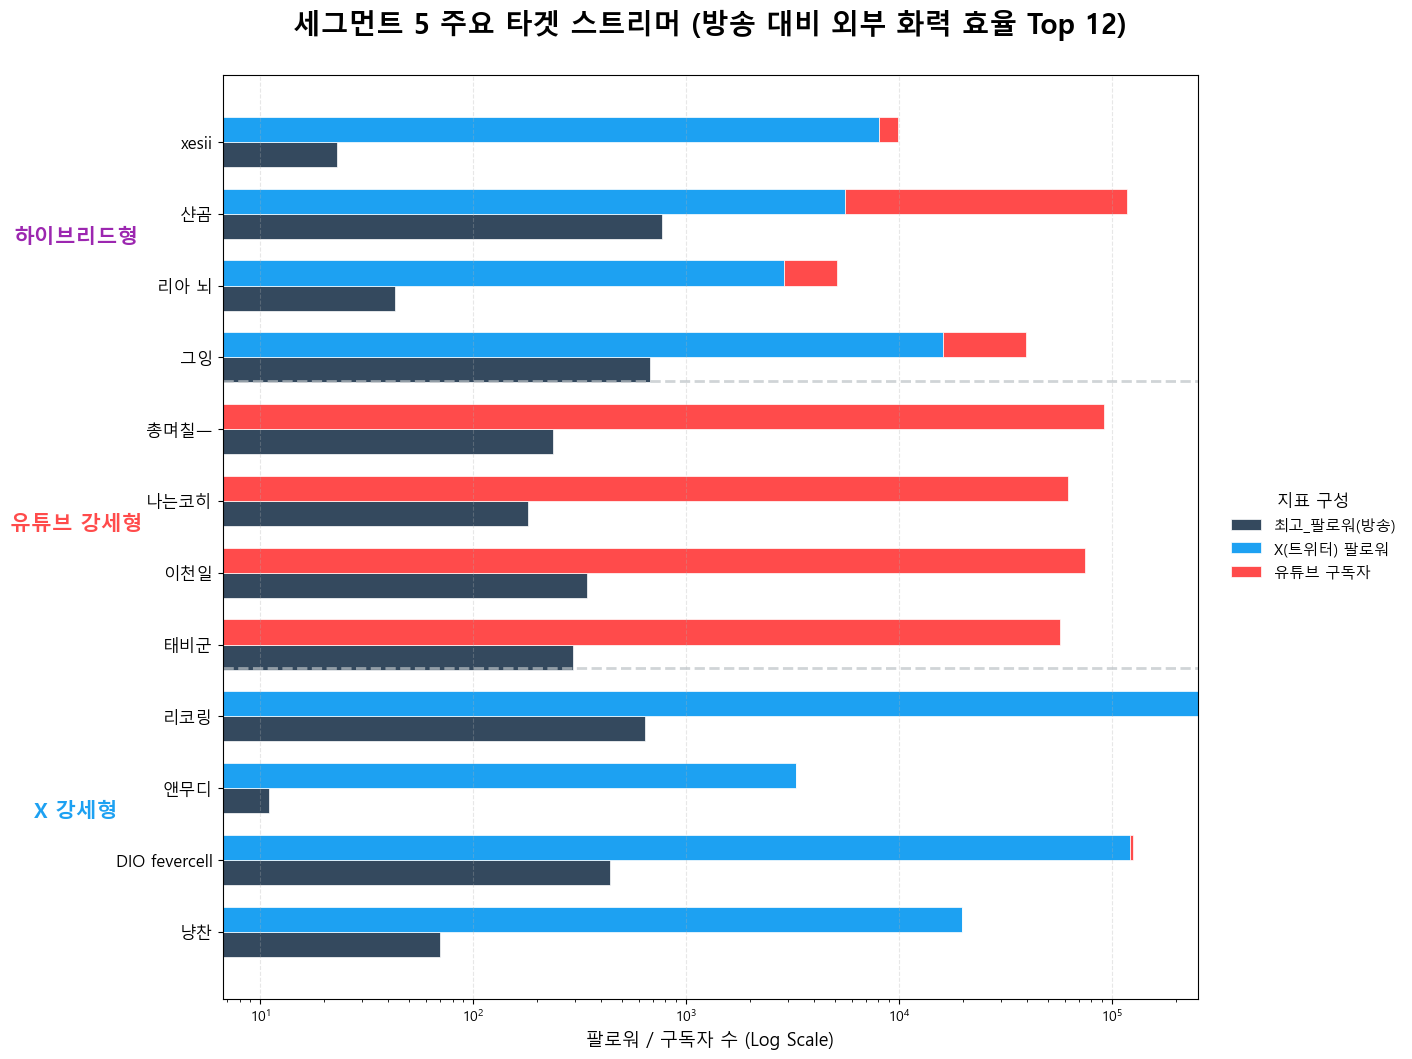

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# 원본 보호를 위해 복사본 사용
plot_df = segment_5_df.copy()

# (X 팔로워 + 유튜브 구독자)를 방송 체급(최고_팔로워)으로 나눈 효율성(비율) 계산
plot_df['외부_활성도_비율'] = (plot_df['X_팔로워'] + plot_df['유튜브_구독자']) / plot_df['최고_팔로워']

# 각 그룹 필터링
group_hb = plot_df[plot_df['유입경로'] == '하이브리드 (유튜브+X)']
group_yt = plot_df[plot_df['유입경로'] == '유튜브 강세형']
group_x = plot_df[plot_df['유입경로'] == 'X(트위터) 강세형']

# 효율성(비율) 기준 상위 4명 추출 (그래프 상단에 가장 효율이 좋은 사람이 오도록 오름차순 정렬)
top4_hb = group_hb.nlargest(4, '외부_활성도_비율').sort_values('외부_활성도_비율', ascending=True)
top4_yt = group_yt.nlargest(4, '외부_활성도_비율').sort_values('외부_활성도_비율', ascending=True)
top4_x = group_x.nlargest(4, '외부_활성도_비율').sort_values('외부_활성도_비율', ascending=True)

# 데이터 합치기 (그래프가 아래에서 위로 그려지므로 X -> 유튜브 -> 하이브리드 순으로 쌓음)
top12_df = pd.concat([top4_x, top4_yt, top4_hb]).reset_index(drop=True)



plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)    

fig, ax = plt.subplots(figsize=(15, 12)) 

# Y축 위치 및 막대 두께 설정
ind = np.arange(len(top12_df))
width = 0.35 

# [막대 1] 최고_팔로워 (방송 내부 체급)
ax.barh(ind, top12_df['최고_팔로워'], width, 
        label='최고_팔로워(방송)', color='#34495E', 
        edgecolor='white', linewidth=0.5)

# [막대 2] 외부 플랫폼 화력 (스택형)
ax.barh(ind + width, top12_df['X_팔로워'], width, 
        label='X(트위터) 팔로워', color='#1DA1F2', 
        edgecolor='white', linewidth=0.5)

ax.barh(ind + width, top12_df['유튜브_구독자'], width, 
        left=top12_df['X_팔로워'], 
        label='유튜브 구독자', color='#FF4B4B', 
        edgecolor='white', linewidth=0.5)

# 축 설정 및 제목 (절대적인 규모 차이가 있으므로 로그 스케일 유지)
ax.set_xscale('log')
ax.set_yticks(ind + width / 2)
ax.set_yticklabels(top12_df['스트리머명'], fontsize=12)

# 제목 수정 (기준 명시)
ax.set_title('세그먼트 5 주요 타겟 스트리머 (방송 대비 외부 화력 효율 Top 12)', fontsize=20, pad=30, fontweight='bold')
ax.set_xlabel('팔로워 / 구독자 수 (Log Scale)', fontsize=13)
ax.set_ylabel('') 

# 범례 그래프 오른쪽 밖으로 빼기
ax.legend(title='지표 구성', loc='center left', bbox_to_anchor=(1.02, 0.5), 
          fontsize=11, title_fontsize=12, frameon=False)

# 그룹명을 나누는 가이드라인 점선
plt.axhline(y=3.85, color='#BDC3C7', linestyle='--', linewidth=2, alpha=0.7)
plt.axhline(y=7.85, color='#BDC3C7', linestyle='--', linewidth=2, alpha=0.7)

# 그룹명 텍스트 (Y축 왼쪽 바깥에 고정)
ax.text(-0.15, 1.85, 'X 강세형', color='#1DA1F2', fontsize=15, fontweight='bold', va='center', ha='center', transform=ax.get_yaxis_transform())
ax.text(-0.15, 5.85, '유튜브 강세형', color='#FF4B4B', fontsize=15, fontweight='bold', va='center', ha='center', transform=ax.get_yaxis_transform())
ax.text(-0.15, 9.85, '하이브리드형', color='#9C27B0', fontsize=15, fontweight='bold', va='center', ha='center', transform=ax.get_yaxis_transform())

# 기타 디테일 정리
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.subplots_adjust(left=0.2, right=0.85)

plt.show()

1. "방송 체급은 숫자에 불과하다" (압도적 유입 잠재력)

모든 스트리머의 어두운 회색 막대(방송 팔로워)보다 컬러 막대(외부 화력)가 압도적으로 길다. 
특히 xesii나 리아 뇌 같은 스트리머는 방송 체급 대비 외부 화력이 수십 배 이상 차이 납니다.

영입 전략: 이들에게는 "방송 성장을 도와주겠다"는 말보다, "당신의 수만 명 팬들이 씨미(CIME)로 편하게 놀러 올 수 있는 통로(알림 시스템, SNS 연동)를 제공하겠다"는 기술적 메리트가 훨씬 강력하게 먹히지 않을까

2. 그룹별 타겟팅의 차별화 (유형별 맞춤 제안)

유튜브 강세형 : X(트위터) 비중이 거의 없고 유튜브가 90% 이상. 이들은 '영상 기획자'에 가깝다. 실시간 방송 중 나온 하이라이트를 유튜브 쇼츠로 빠르게 퍼뜨릴 수 있는 씨미만의 '쇼츠 제작 툴'을 어필이 필요하다.

X 강세형 : 유튜브보다 X 팔로워가 압도적. 이들은 '서브컬처 인플루언서'입니다. 팬들과의 끈끈한 유대감이 강점이므로, 씨미 플랫폼 내에 '팬아트 게시판'이나 '작가 전용 커스텀 아이템' 기능을 강조하면 효과적.

3. '하이브리드형'의 희소성과 가치

데이터 포인트: 산곰, 그잉 같은 하이브리드형은 유튜브와 X 막대 색깔이 골고루 섞여 있으며, 전체 외부 화력도 최상위권(10만 명 이상)입니다.

영입 전략: 이들은 기획력과 팬덤 결집력을 모두 갖춘 '준완성형' 모델입니다. 씨미 플랫폼의 '초기 앰배서더'급 대우를 제안하며, 양쪽 플랫폼의 팬들을 모두 흡수할 수 있는 이벤트를 기획해야 한다.

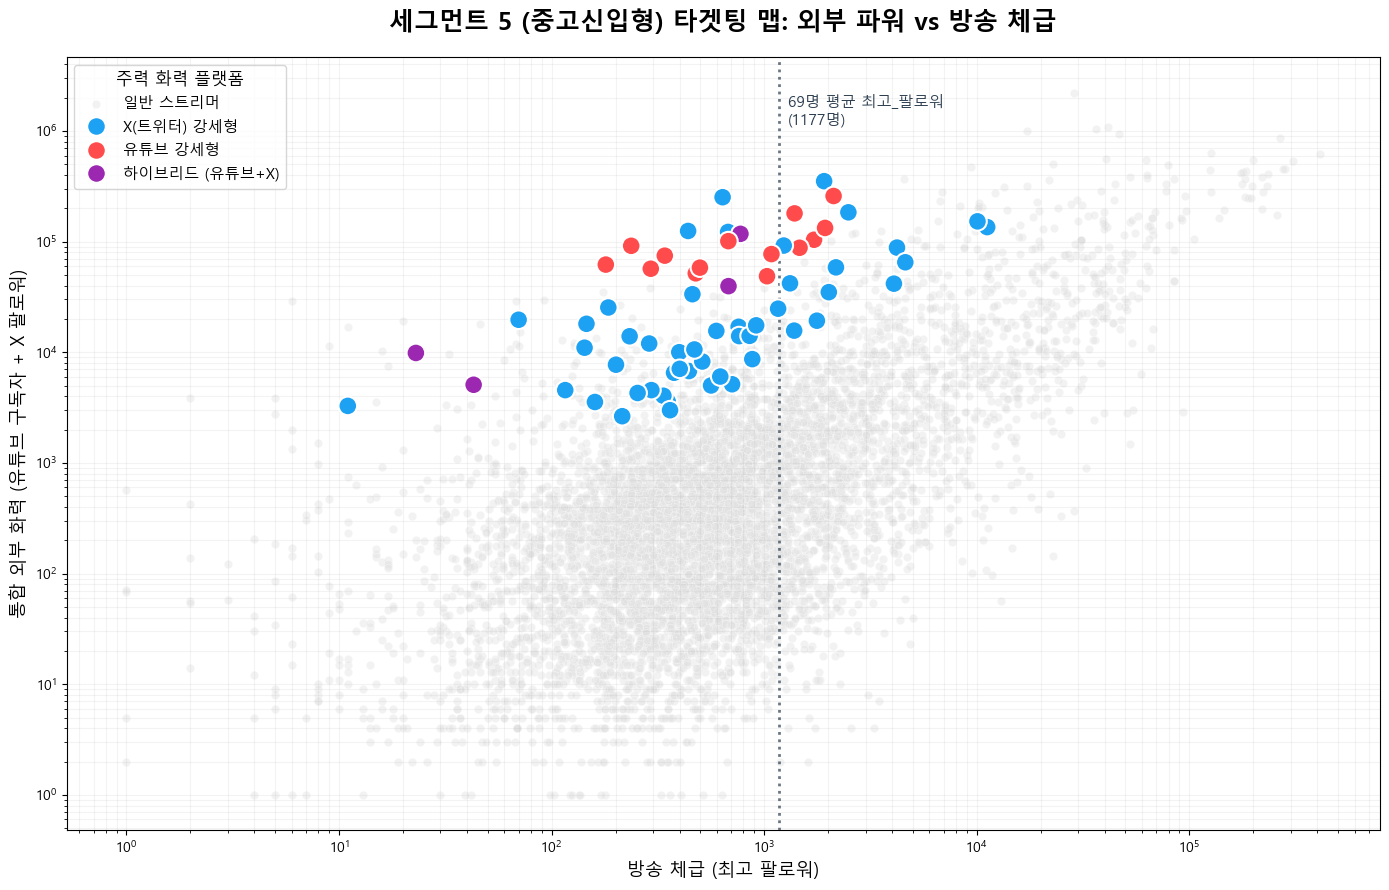

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 통합 외부 화력 (Y축) 생성
df['통합_외부화력'] = df['유튜브_구독자'] + df['X_팔로워']
segment_5_df = segment_5_df.copy()
segment_5_df['통합_외부화력'] = segment_5_df['유튜브_구독자'] + segment_5_df['X_팔로워']

# 2. TOP 200 기준 커트라인 재계산 (에러 방지)
yt_inflow_cut = df.nlargest(200, '유튜브_유입지수')['유튜브_유입지수'].min()
x_inflow_cut = df.nlargest(200, 'X_유입지수')['X_유입지수'].min()

# 3. 유입 경로 그룹핑 (69명의 출신 성분 분석)
def assign_group(row):
    is_yt = row['유튜브_유입지수'] >= yt_inflow_cut
    is_x = row['X_유입지수'] >= x_inflow_cut
    
    if is_yt and is_x: return '하이브리드 (유튜브+X)'
    if is_yt: return '유튜브 강세형'
    if is_x: return 'X(트위터) 강세형'
    return '기타(기준치 근접)'

segment_5_df['유입경로'] = segment_5_df.apply(assign_group, axis=1)

# 4. 시각화 세팅
plt.figure(figsize=(14, 9))
plt.rc('font', family='Malgun Gothic') # 윈도우용 한글 폰트
plt.rc('axes', unicode_minus=False)

# 배경: 전체 스트리머
sns.scatterplot(data=df, x='최고_팔로워', y='통합_외부화력', 
                color='#E0E0E0', alpha=0.4, label='일반 스트리머')

# 타겟: 중고신입형 69명 (유입 경로별 색상 매핑)
palette = {
    '유튜브 강세형': '#FF4B4B',        # 강렬한 레드
    'X(트위터) 강세형': '#1DA1F2',     # 트위터 블루
    '하이브리드 (유튜브+X)': '#9C27B0',  # 보라
    '기타(기준치 근접)': '#7F8C8D'
}

sns.scatterplot(data=segment_5_df, x='최고_팔로워', y='통합_외부화력', 
                hue='유입경로', palette=palette, s=180, 
                edgecolor='white', linewidth=1.5, zorder=5)

# 축 설정 (데이터 편차가 크므로 로그 스케일 유지)
plt.xscale('log')
plt.yscale('log')

# 가이드라인 (최종 69명의 평균치 표시)
avg_broadcast = segment_5_df['최고_팔로워'].mean()
plt.axvline(x=avg_broadcast, color='#2C3E50', linestyle=':', linewidth=2, alpha=0.7)
plt.text(avg_broadcast * 1.1, df['통합_외부화력'].max() * 0.5, 
         f'69명 평균 최고_팔로워\n({int(avg_broadcast)}명)', color='#2C3E50', fontsize=11)

# 타이틀 및 레이블
plt.title('세그먼트 5 (중고신입형) 타겟팅 맵: 외부 파워 vs 방송 체급', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('방송 체급 (최고 팔로워)', fontsize=13)
plt.ylabel('통합 외부 화력 (유튜브 구독자 + X 팔로워)', fontsize=13)

# 범례
plt.legend(title='주력 화력 플랫폼', loc='upper left', fontsize=11, title_fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.15)

plt.tight_layout()
plt.show()

1. 동일 방송 체급 대비 높은 외부 팬덤 규모

세그먼트 5 그룹은 동일한 방송 체급(최고 팔로워 기준)의 일반 스트리머 대비 상대적으로 높은 외부 플랫폼 영향력을 보이는 경향이 나타났다.
이는 방송 내부 성장 이전에 외부 플랫폼에서 팬덤이 먼저 형성된 사례가 존재할 가능성을 시사한다.

2. X(트위터) 기반 성장형 비중이 높게 나타남

세그먼트 5에서는 X(트위터) 강세형 스트리머 비중이 높게 나타났다.
이는 버튜버 시장에서 실시간 소통, 팬아트, 커뮤니티 중심의 서브컬처 팬덤 구조가 중요한 성장 경로로 작용하고 있을 가능성을 보여준다.

또한 이미 외부 커뮤니티 기반 팬층을 보유한 스트리머들은 플랫폼 내 초기 정착 가능성이 상대적으로 높을 수 있다.

3. 일부 하이브리드/유튜브 강세형의 높은 외부 화력 확인

일부 하이브리드형 및 유튜브 강세형 스트리머들은 방송 체급 대비 매우 높은 외부 플랫폼 영향력을 보였다.
특히 유튜브 기반 성장형의 경우 콘텐츠 확산력과 알고리즘 노출 효과를 기반으로 대규모 팬덤이 형성되는 경향이 일부 확인되었다.

4. 외부 팬덤의 ‘방송 전환’ 가능성에 주목할 필요

세그먼트 5 스트리머들은 완전히 신규 팬덤을 형성해야 하는 유형이라기보다, 이미 보유한 외부 팬층을 생방송 플랫폼 이용자로 전환할 가능성이 있는 그룹으로 해석할 수 있다.

따라서 플랫폼 차원에서는:

알림 연동
클립/숏폼 공유
SNS 기반 유입 이벤트
팬 커뮤니티 기능 강화

등 외부 팬덤 유입 및 전환을 지원하는 전략이 중요할 수 있다.

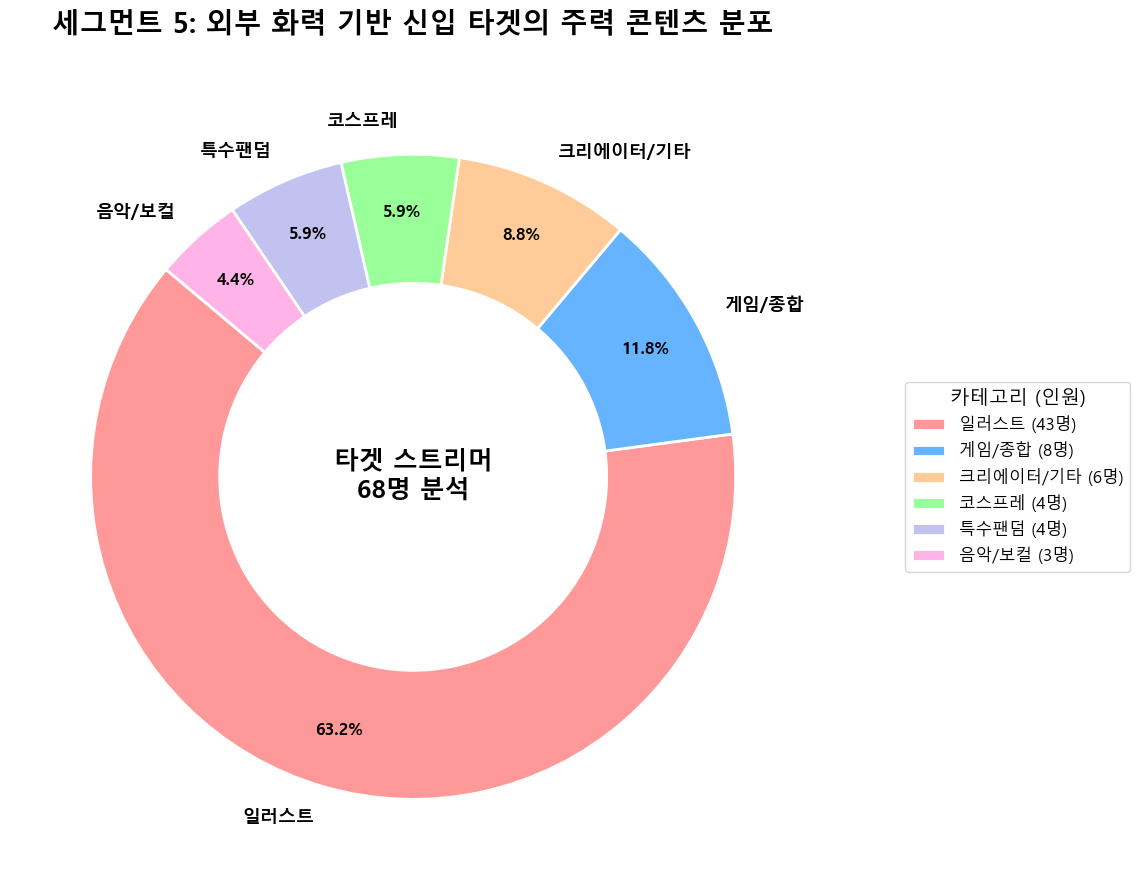

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================================================
# 1. 다현님이 수집하신 데이터 (CSV 없이 바로 실행되도록 리스트화)
# =====================================================================
data = {
    '카테고리': [
        '그림', '그림', '그림', '노래', '그림', '그림', '그림', '그림', '그림', '그림', 
        '그림', '그림', '그림', '그림', '그림', '그림', '그림', '그림', '그림', '그림', 
        '그림', '버튜버', '코스프레', '특수팬덤', '그림', '그림', '특수팬덤', '그림', '그림', '그림', 
        '코스프레', '그림', '그림', '그림', '그림', '그림', '그림', '코스프레', '그림', 
        '그림', '그림', '그림', '코스프레', '특수팬덤', '특수팬덤', '그림', '그림', '노래', '그림', 
        '게임', '그림', '그림', '그림', '그림', '유튜브', '인터넷방송인클립제작', '유튜브', '게임', '게임', 
        '여행/일상', '게임', '공포유튜브', '게임', '노래', '게임', '그림', '게임', '게임'
    ]
}

# 딕셔너리를 pandas 데이터프레임으로 변환
df_new = pd.DataFrame(data)

# =====================================================================
# 2. 발표용으로 카테고리명 예쁘게 다듬기 (파생 컬럼 '정제된_카테고리' 생성)
# =====================================================================
def refine_category(cat):
    if cat == '그림': return '일러스트'
    if cat == '게임': return '게임/종합'
    if cat == '노래': return '음악/보컬'
    if cat in ['코스프레', '특수팬덤']: return cat # 그대로 사용
    # 유튜브, 버튜버, 팀계정, 인터넷방송인클립제작, 여행/일상, 공포유튜브 등 1~2명 항목은 하나로 묶기
    return '크리에이터/기타'

df_new['정제된_카테고리'] = df_new['카테고리'].apply(refine_category)

# =====================================================================
# 3. 데이터 집계
# =====================================================================
cat_counts = df_new['정제된_카테고리'].value_counts()
labels = cat_counts.index
sizes = cat_counts.values

# =====================================================================
# 4. 차트 디자인 (파스텔톤 6색) 및 출력
# =====================================================================
colors = ['#FF9999', '#66B3FF', '#FFCC99', '#99FF99', '#C2C2F0', '#FFB3E6']

fig, ax = plt.subplots(figsize=(11, 9))
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 도넛 차트 그리기
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', 
                                  startangle=140, colors=colors[:len(labels)], 
                                  pctdistance=0.82, 
                                  wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))

# 텍스트 폰트/크기 설정
for t in texts:
    t.set_fontsize(13)
    t.set_fontweight('bold')
for at in autotexts:
    at.set_fontsize(12)
    at.set_color('black')
    at.set_fontweight('bold')

# 도넛 정중앙 텍스트 (전체 인원수 자동 계산)
plt.text(0, 0, f"타겟 스트리머\n{len(df_new)}명 분석", ha='center', va='center', fontsize=18, fontweight='bold')

plt.title('세그먼트 5: 외부 화력 기반 신입 타겟의 주력 콘텐츠 분포', fontsize=20, pad=30, fontweight='bold')

# 범례 깔끔하게 우측 배치
ax.legend(wedges, [f"{l} ({s}명)" for l, s in zip(labels, sizes)], 
          title="카테고리 (인원)", loc="center left", bbox_to_anchor=(1.1, 0.5), 
          fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()